In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
import seaborn as sns

In [3]:
df1 = pd.read_excel('./GLM_Adults_intercept_probabilities.xlsx')

In [4]:
df1.head()

,Suffix,Property,Mean intercept,CI low,CI High
0,aF,APU,0.225551,0.198980,0.254542
1,aF,PU,0.759305,0.729282,0.786970
2,iF,APU,0.107787,0.090508,0.127900
3,iF,PU,0.805470,0.778608,0.829785
4,iN,APU,0.035484,0.027648,0.045437


In [5]:
df2 = pd.read_excel('./ForSimulation_Adults_with_Tokens.xlsx')

In [6]:
df2.head()

,Class,Property,Lexical_p0,Experimental_phat,Raw_successes,n_limiting,Token_p0
0,aF,APU,0.2259,0.269841,255,105,0.1503
1,aF,PU,0.5810,0.711111,672,105,0.7657
2,iF,APU,0.6017,0.140741,133,105,0.5359
3,iF,PU,0.1576,0.760847,719,105,0.2818
4,iN,APU,0.0097,0.084656,80,105,0.0177


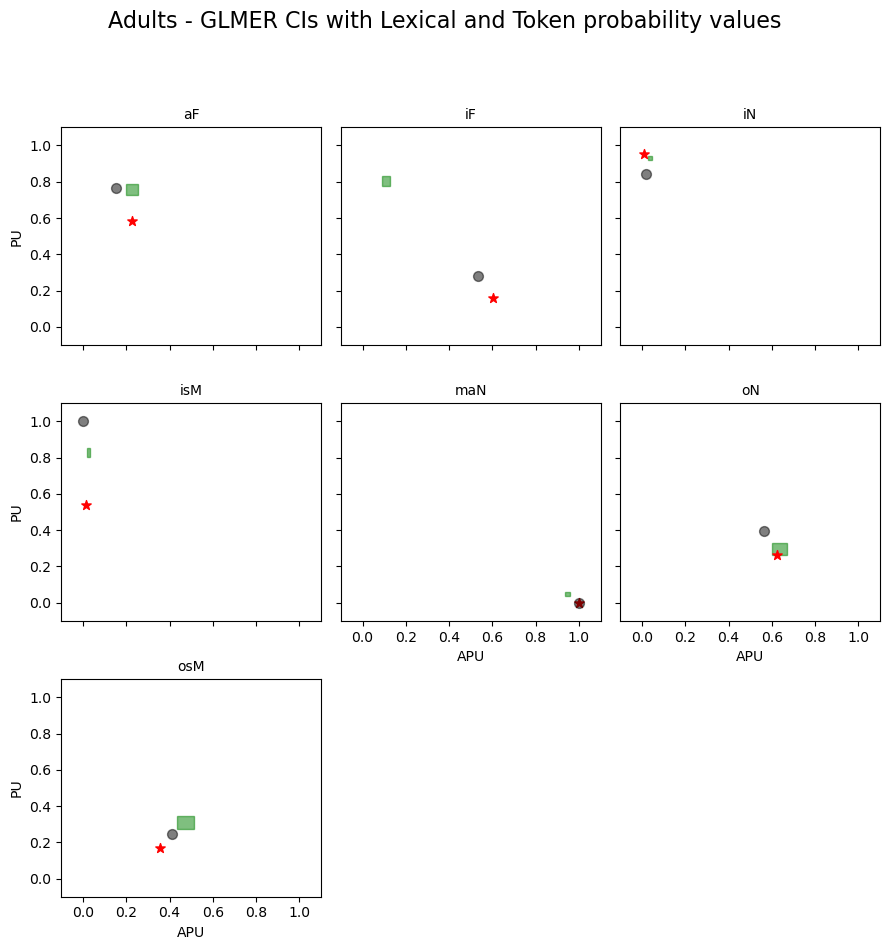

In [7]:
title = "Adults - GLMER CIs with Lexical and Token probability values"
outfile = "GLM_Figure_Adults.pdf"

def plot_rect(data, **kwargs):
    apu_row = data[data['Property'] == 'APU']
    pu_row = data[data['Property'] == 'PU']
    if len(apu_row) == 1 and len(pu_row) == 1:
        apu_ci_low = apu_row['CI low'].iloc[0]
        apu_ci_high = apu_row['CI High'].iloc[0]
        pu_ci_low = pu_row['CI low'].iloc[0]
        pu_ci_high = pu_row['CI High'].iloc[0]
        ax = plt.gca()
        rect = plt.Rectangle((apu_ci_low, pu_ci_low), apu_ci_high - apu_ci_low, pu_ci_high - pu_ci_low, color='green', alpha=0.5)
        ax.add_patch(rect)
    
    # Add points from df2
    suffix = data['Suffix'].iloc[0]
    df2_subset = df2[df2['Class'] == suffix]
    if len(df2_subset) == 2:  # APU and PU rows
        apu_lex = df2_subset[df2_subset['Property'] == 'APU']['Lexical_p0'].iloc[0]
        pu_lex = df2_subset[df2_subset['Property'] == 'PU']['Lexical_p0'].iloc[0]
        apu_tok = df2_subset[df2_subset['Property'] == 'APU']['Token_p0'].iloc[0]
        pu_tok = df2_subset[df2_subset['Property'] == 'PU']['Token_p0'].iloc[0]
        ax.scatter(apu_lex, pu_lex, color='red', marker='*', s=50)
        ax.scatter(apu_tok, pu_tok, color='black', marker='o', s=50, alpha=0.5)

g = sns.FacetGrid(df1, col='Suffix', col_wrap=3, sharex=True, sharey=True, despine=False)
g.map_dataframe(plot_rect)

# Ensure vertical axis includes 1.0 tick
g.set(ylim=(-0.1, 1.1))
g.set(xlim=(-0.1, 1.1))
yticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
xticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
for ax in g.axes.flat:
    ax.set_yticks(yticks)
    ax.set_xticks(xticks)

g.set_axis_labels('APU', 'PU')
g.set_titles(col_template="{col_name}")
plt.suptitle(title, fontsize=16, y=1.05)
plt.savefig(outfile, bbox_inches='tight')
plt.tight_layout()
plt.show()